# SMOTE-NC Comparison: Class-Weighting vs Synthetic Oversampling

UK RMBS loan-level data. Secondary/contextual content - tests whether SMOTE-NC oversampling improves LR/RF predictive performance over the class-weighting approach used in `ml_comparison_model.ipynb`. Does not touch RQ1 or the inferential baseline model.

SMOTE-NC (not vanilla SMOTE) is used because most predictors here are dummy-encoded categoricals; vanilla SMOTE's linear interpolation would produce nonsensical fractional dummy values (e.g. `PropType_Flat=0.5`). SMOTE-NC (Chawla et al., 2002 extension) handles categorical columns via majority-vote among neighbors instead of interpolation.

**Literature context:** van den Goorbergh et al. (2022, *J Clin Epidemiol*) found SMOTE/class-balancing techniques did not improve AUC over class-weighting on comparable rare-event prediction tasks, and worsened calibration - this script tests that finding empirically on this data rather than assuming it holds.

## Setup

In [1]:
# pip install imbalanced-learn - not preinstalled in Colab by default
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    classification_report, confusion_matrix,
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline  # NOT sklearn's Pipeline -
                                                          # resamples inside each CV fold
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss


def youdens_j_threshold(y_true, y_pred_prob):
    """Threshold maximising Youden's J = TPR - FPR (Youden, 1950) - same
    quantity as the KS statistic used for cutoffs in credit scoring
    (Hand & Henley, 1997). Mirrors the threshold logic already used in
    the inference and ML-comparison scripts for consistency."""
    fpr, tpr, thresh = roc_curve(y_true, y_pred_prob)
    return thresh[np.argmax(tpr - fpr)]


from google.colab import drive
drive.mount("/content/drive")

DATA_FOLDER = "/content/drive/MyDrive/Dissertation/data2"
RANDOM_STATE = 42

Mounted at /content/drive


In [2]:
# Okabe-Ito palette, continued from the other scripts
PALETTE = {
    "primary": "#0072B2", "highlight": "#D55E00", "secondary": "#009E73",
    "tertiary": "#E69F00", "neutral": "#3A3A3A",
}
plt.rcParams.update({
    "axes.edgecolor": PALETTE["neutral"], "axes.labelcolor": PALETTE["neutral"],
    "xtick.color": PALETTE["neutral"], "ytick.color": PALETTE["neutral"],
    "text.color": PALETTE["neutral"], "axes.grid": True,
    "grid.color": "#D9D9D9", "grid.linewidth": 0.5, "figure.dpi": 110,
})
FIGURE_COUNTER = {"n": 25}  # continues from the ML-comparison script,
                            # whose figures now run 22-25 after its own
                            # counter was corrected to start at 21


def styled_figure(title, xlabel, ylabel):
    FIGURE_COUNTER["n"] += 1
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.set_title(f"Figure {FIGURE_COUNTER['n']}: {title}",
                 fontsize=11, fontweight="bold", color=PALETTE["neutral"], pad=12)
    ax.set_xlabel(xlabel, fontsize=9.5)
    ax.set_ylabel(ylabel, fontsize=9.5)
    return fig, ax

## Step 1: Load Data

Same predictor set as `ml_comparison_model.ipynb`, for direct comparability.

In [3]:
df = pd.read_csv(f"{DATA_FOLDER}/cleaned_dissertation_data.csv", low_memory=False)
print(f"Loaded: {len(df):,} rows, {df.shape[1]} cols, "
      f"default rate = {df['default'].mean():.2%}")

predictors = [
    "Original_LTV", "Interest_Rate", "Loan_Term", "Income_log",
    "PropType_Flat", "PropType_Bungalow", "PropType_Terraced",
    "Purpose_Remortgage", "Purpose_DebtConsolidation", "Purpose_Renovation",
    "Purpose_RemortgageEquityRelease", "Purpose_Other", "IncVerif_Other",
]
X = df[predictors].astype(float)
y = df["default"].astype(int)

# indices 0-3 are continuous (Original_LTV, Interest_Rate, Loan_Term,
# Income_log); everything from index 4 onward is a 0/1 dummy - tell
# SMOTENC which columns to treat as categorical
categorical_idx = list(range(4, len(predictors)))
print(f"Categorical column indices for SMOTE-NC: {categorical_idx} "
      f"({[predictors[i] for i in categorical_idx]})")

Loaded: 163,348 rows, 61 cols, default rate = 1.05%
Categorical column indices for SMOTE-NC: [4, 5, 6, 7, 8, 9, 10, 11, 12] (['PropType_Flat', 'PropType_Bungalow', 'PropType_Terraced', 'Purpose_Remortgage', 'Purpose_DebtConsolidation', 'Purpose_Renovation', 'Purpose_RemortgageEquityRelease', 'Purpose_Other', 'IncVerif_Other'])


## Step 2: Train/Test Split and Reproducibility Check

80/20 stratified split, identical parameters to `ml_comparison_model.ipynb`. The index hash below confirms both scripts evaluate on the same held-out rows - required for the comparison in Step 6 to be valid.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows, {y_train.sum():,} events "
      f"({y_train.mean():.2%})")
print(f"Test: {len(X_test):,} rows, {y_test.sum():,} events "
      f"({y_test.mean():.2%}) - held out untouched, never resampled")

test_index_hash = hashlib.md5(
    ",".join(map(str, sorted(X_test.index))).encode()
).hexdigest()
print(f"Test-set index hash: {test_index_hash}")
print("Compare this against the same check run in ml_comparison_model.ipynb - "
      "matching hashes confirm both scripts evaluated on the same held-out rows.")

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 130,678 rows, 1,377 events (1.05%)
Test: 32,670 rows, 344 events (1.05%) - held out untouched, never resampled
Test-set index hash: e3895d473eed1bf075aca9aaba705456
Compare this against the same check run in ml_comparison_model.ipynb - matching hashes confirm both scripts evaluated on the same held-out rows.


## Step 3a: Tune Logistic Regression with SMOTE-NC

Scaler runs **before** SMOTE in the pipeline - SMOTENC's neighbour search is distance-based, and unscaled continuous predictors with very different ranges (e.g. `Loan_Term` ~26-599 vs `Interest_Rate` ~0-8) would otherwise dominate the distance metric, distorting which synthetic examples get generated. Scaling all columns (including the 0/1 dummies) is harmless for SMOTENC's categorical handling, which matches on equality rather than distance for those columns regardless of their numeric labels.

`sampling_strategy="auto"` balances minority:majority to 1:1 within each fold's training partition - the standard default for this kind of comparison (matches van den Goorbergh et al.'s setup).

In [5]:
# Grid extended below 0.001 after an earlier run selected the smallest
# value offered. A hyperparameter chosen at the edge of its own grid means
# the search never bracketed the optimum, so the model's measured
# performance is conditional on where the grid stopped - which would
# undercut this script's whole conclusion, since a SMOTE-NC model that
# underperforms because it was under-tuned is not evidence about SMOTE-NC.
lr_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTENC(categorical_features=categorical_idx,
                      sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),  # no class_weight -
                                                                 # SMOTE handles balance
])
lr_smote_grid = {"clf__C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
lr_smote_search = GridSearchCV(
    lr_smote_pipeline, lr_smote_grid, cv=inner_cv, scoring="average_precision", n_jobs=-1
)
lr_smote_search.fit(X_train, y_train)
print(f"Best SMOTE-NC LR: C={lr_smote_search.best_params_['clf__C']}, "
      f"CV PR-AUC={lr_smote_search.best_score_:.4f}")


def report_grid_boundaries(search, grid, label):
    """Flag any tuned hyperparameter selected at the edge of its own grid.

    Mirrors the identical check in ml_comparison_model4_gridsearchCV.ipynb,
    so both sides of the class-weighting vs SMOTE-NC comparison are held to
    the same tuning standard."""
    boundary = []
    for param, values in grid.items():
        chosen = search.best_params_[param]
        if len(values) > 1 and chosen in (min(values), max(values)):
            boundary.append(f"{param}={chosen} (grid {min(values)}-{max(values)})")
    if boundary:
        print(f"{label}: BOUNDARY selection on {', '.join(boundary)} - the "
              f"optimum is not bracketed; widen the grid before comparing "
              f"this model's performance against the class-weighted version.")
    else:
        print(f"{label}: all tuned hyperparameters selected in the interior "
              f"of their grids - the optimum is bracketed.")


report_grid_boundaries(lr_smote_search, lr_smote_grid, "SMOTE-NC LR")


Best SMOTE-NC LR: C=1e-05, CV PR-AUC=0.0208
SMOTE-NC LR: BOUNDARY selection on clf__C=1e-05 (grid 1e-05-100) - the optimum is not bracketed; widen the grid before comparing this model's performance against the class-weighted version.


## Step 3b: Tune Random Forest with SMOTE-NC

Same scaler-before-SMOTE ordering and grid as `ml_comparison_model.ipynb`'s Random Forest step, for a like-for-like comparison.

In [7]:
# Grid matched exactly to ml_comparison_model4_gridsearchCV.ipynb's
# (extended) Random Forest grid. Like-for-like tuning is the precondition
# for the Step 6 comparison meaning anything: if the two versions of the
# same model searched different spaces, a performance gap between them
# would be partly a gap in search effort.
rf_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTENC(categorical_features=categorical_idx,
                      sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),  # no
                                                            # class_weight, same reason
])
rf_smote_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [3, 5, 10, 20],
    "clf__min_samples_leaf": [5, 20, 50, 100],
}
rf_smote_search = GridSearchCV(
    rf_smote_pipeline, rf_smote_grid, n_jobs=-1, cv=inner_cv,
    scoring="average_precision",
)
rf_smote_search.fit(X_train, y_train)
print(f"Best SMOTE-NC RF: {rf_smote_search.best_params_}, "
      f"CV PR-AUC={rf_smote_search.best_score_:.4f}")
report_grid_boundaries(rf_smote_search, rf_smote_grid, "SMOTE-NC RF")

smote_models = {
    "Logistic Regression (SMOTE-NC)": lr_smote_search.best_estimator_,
    "Random Forest (SMOTE-NC)": rf_smote_search.best_estimator_,
}


Best SMOTE-NC RF: {'clf__max_depth': 5, 'clf__min_samples_leaf': 50, 'clf__n_estimators': 100}, CV PR-AUC=0.0214
SMOTE-NC RF: BOUNDARY selection on clf__n_estimators=100 (grid 100-200) - the optimum is not bracketed; widen the grid before comparing this model's performance against the class-weighted version.


## Step 4: Test-Set Evaluation

Single evaluation on the held-out test set, touched once per model, using each model's tuned SMOTE-NC pipeline.

In [8]:
smote_results = {}
for name, model in smote_models.items():
    test_pred = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_pred)
    pr_auc = average_precision_score(y_test, test_pred)
    smote_results[name] = {"pred": test_pred, "roc_auc": roc_auc, "pr_auc": pr_auc}
    print(f"{name}: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")

Logistic Regression (SMOTE-NC): ROC-AUC=0.6825, PR-AUC=0.0217
Random Forest (SMOTE-NC): ROC-AUC=0.7041, PR-AUC=0.0228


## Step 5: Classification Reports (Precision/Recall/F1 per Class)

Mirrors `ml_comparison_model.ipynb`'s equivalent step, so both comparisons report the same operating-threshold detail, not just AUC summary stats. Threshold selection stays leakage-safe: Youden's J threshold is derived from each model's training-set out-of-fold predictions (`cross_val_predict`, same `inner_cv` used for hyperparameter tuning), never from the test set directly. `cross_val_predict` refits the full pipeline (scaler + SMOTENC + classifier) fresh on each fold's training partition, so the resampling step is correctly re-run inside each fold here too, not just during tuning.

In [9]:
for name, model in smote_models.items():
    oof_pred = cross_val_predict(
        model, X_train, y_train, cv=inner_cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    threshold = youdens_j_threshold(y_train, oof_pred)
    test_pred_class = (smote_results[name]["pred"] >= threshold).astype(int)
    print(f"\n{name} (threshold={threshold:.4f}):")
    print(classification_report(y_test, test_pred_class,
                                 target_names=["No Default", "Default"], digits=4))
    cm = confusion_matrix(y_test, test_pred_class, labels=[0, 1])
    cm_df = pd.DataFrame(
        cm, index=["Actual: No Default", "Actual: Default"],
        columns=["Predicted: No Default", "Predicted: Default"]
    )
    print(f"Confusion matrix ({name}, test set, n={len(y_test):,}):")
    print(cm_df)


Logistic Regression (SMOTE-NC) (threshold=0.4793):
              precision    recall  f1-score   support

  No Default     0.9959    0.4864    0.6536     32326
     Default     0.0165    0.8110    0.0324       344

    accuracy                         0.4898     32670
   macro avg     0.5062    0.6487    0.3430     32670
weighted avg     0.9856    0.4898    0.6471     32670

Confusion matrix (Logistic Regression (SMOTE-NC), test set, n=32,670):
                    Predicted: No Default  Predicted: Default
Actual: No Default                  15724               16602
Actual: Default                        65                 279

Random Forest (SMOTE-NC) (threshold=0.4726):
              precision    recall  f1-score   support

  No Default     0.9958    0.4962    0.6623     32326
     Default     0.0167    0.8023    0.0326       344

    accuracy                         0.4994     32670
   macro avg     0.5062    0.6492    0.3475     32670
weighted avg     0.9855    0.4994    0.6557   

## Step 6: Class-Weighting vs SMOTE-NC Comparison

Loaded from `ml_comparison_model.ipynb`'s saved output, not hardcoded, so this stays correct if that script is ever re-run.

In [10]:
weighted_summary = pd.read_csv(f"{DATA_FOLDER}/model_comparison_summary.csv", index_col=0)


def smote_metrics(name):
    """Pull ROC-AUC/PR-AUC out of a smote_results entry as floats.

    astype(float) is load-bearing, not decorative: smote_results[name] also
    holds the raw prediction array, so pd.Series() on it returns an
    object-dtype Series. .round() is a silent no-op on object dtype, which
    left the SMOTE-NC columns unrounded next to rounded class-weighted ones
    in an earlier run - output that looked fine and was quietly
    inconsistent, including in the exported CSV."""
    return (pd.Series(smote_results[name])
            .loc[["roc_auc", "pr_auc"]]
            .astype(float)
            .rename({"roc_auc": "ROC-AUC", "pr_auc": "PR-AUC"}))


comparison = pd.DataFrame({
    "LR (class-weighted)": weighted_summary.loc["Logistic Regression"].astype(float),
    "LR (SMOTE-NC)": smote_metrics("Logistic Regression (SMOTE-NC)"),
    "RF (class-weighted)": weighted_summary.loc["Random Forest"].astype(float),
    "RF (SMOTE-NC)": smote_metrics("Random Forest (SMOTE-NC)"),
}).round(4)
assert comparison.notna().all().all(), (
    "NaNs in the comparison table - the two sources' index labels have "
    "drifted apart and the rows are no longer aligned"
)
print("Class-weighting vs SMOTE-NC comparison:")
print(comparison)
print("\nDifferences are small in absolute terms. The paired bootstrap in "
      "ml_comparison_model4_gridsearchCV.ipynb shows that ROC-AUC gaps of "
      "this size on a 344-event test set are close to the resolution of "
      "the data, so the appropriate claim is that SMOTE-NC does not "
      "improve on class-weighting, not that it is decisively worse.")


Class-weighting vs SMOTE-NC comparison:
         LR (class-weighted)  LR (SMOTE-NC)  RF (class-weighted)  \
ROC-AUC               0.7179         0.6825               0.7127   
PR-AUC                0.0280         0.0217               0.0243   

         RF (SMOTE-NC)  
ROC-AUC         0.7041  
PR-AUC          0.0228  

Differences are small in absolute terms. The paired bootstrap in ml_comparison_model4_gridsearchCV.ipynb shows that ROC-AUC gaps of this size on a 344-event test set are close to the resolution of the data, so the appropriate claim is that SMOTE-NC does not improve on class-weighting, not that it is decisively worse.


## Step 7: Calibration Comparison

This section tests van den Goorbergh et al.'s (2022) claim that class-balancing techniques worsen calibration - the property that a predicted probability matches the observed frequency of the event.

**The comparison needs an unbalanced arm, or it cannot test the claim.** Comparing SMOTE-NC against class-weighting compares two balanced approaches, both of which deliberately shift the intercept away from the true base rate; whichever wins, the literature claim is untouched. The same unweighted logistic regression used as the calibration reference in `ml_comparison_model4_gridsearchCV.ipynb` is therefore refitted here and plotted alongside, purely as a benchmark and never as a competitor in any discrimination comparison. The inference script's full-sample unweighted model (`baseline_LR_model4.ipynb`, Figure 18, Hosmer-Lemeshow p = 0.106) is the corroborating view on the complete data.

**Direction, stated precisely**: curves falling below the diagonal mean observed rates are lower than predicted, so the balanced models **over-predict** default risk. That is the intended consequence of up-weighting the minority class, not a defect of either balancing method.


In [11]:
# Unweighted calibration benchmark, tuned on the same grid and inner CV as
# the SMOTE-NC logistic regression so the only difference between them is
# the imbalance handling. Benchmark only - excluded from every
# discrimination comparison in this script.
from sklearn.pipeline import Pipeline as SkPipeline  # sklearn's, no resampling step

lr_plain_pipeline = SkPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs")),
])
lr_plain_search = GridSearchCV(
    lr_plain_pipeline, {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=inner_cv, scoring="average_precision", n_jobs=-1,
)
lr_plain_search.fit(X_train, y_train)
calibration_reference_pred = lr_plain_search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Calibration benchmark (unweighted, unresampled LR): "
      f"C={lr_plain_search.best_params_['clf__C']}, mean predicted "
      f"probability={calibration_reference_pred.mean():.4f} vs observed "
      f"test-set default rate={y_test.mean():.4f}")


Calibration benchmark (unweighted, unresampled LR): C=1, mean predicted probability=0.0106 vs observed test-set default rate=0.0105


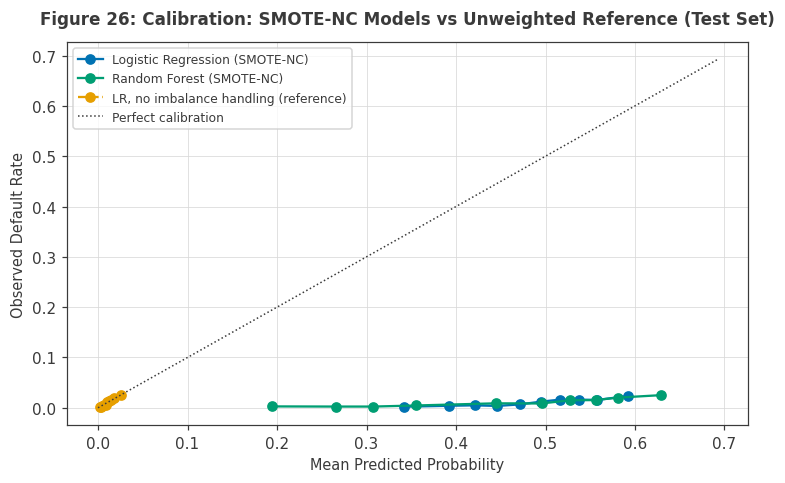

Observed test-set default rate: 0.0105
  Logistic Regression (SMOTE-NC): mean predicted probability 0.4772 (45.3x the base rate, over-predicts default risk)
  Random Forest (SMOTE-NC): mean predicted probability 0.4355 (41.4x the base rate, over-predicts default risk)
  LR, no imbalance handling (reference): mean predicted probability 0.0106 (1.0x the base rate, over-predicts default risk)
Both SMOTE-NC models sit far above the base rate; the unweighted reference sits close to it. Switching from class-weighting to SMOTE-NC does not recover calibration, and the miscalibration tracks whether the data were rebalanced at all rather than which rebalancing method was used - which is the specific claim in van den Goorbergh et al. (2022), tested here rather than assumed.


In [12]:
fig, ax = styled_figure(
    "Calibration: SMOTE-NC Models vs Unweighted Reference (Test Set)",
    "Mean Predicted Probability", "Observed Default Rate"
)
calibration_series = dict(smote_results)
calibration_series["LR, no imbalance handling (reference)"] = {
    "pred": calibration_reference_pred}
colors_smote = {"Logistic Regression (SMOTE-NC)": PALETTE["primary"],
                "Random Forest (SMOTE-NC)": PALETTE["secondary"],
                "LR, no imbalance handling (reference)": PALETTE["tertiary"]}

max_val = 0
mean_pred_summary = {}
for name, res in calibration_series.items():
    calib_df = pd.DataFrame({"pred": res["pred"], "obs": y_test.values})
    calib_df["decile"] = pd.qcut(calib_df["pred"], q=10, duplicates="drop")
    calib = calib_df.groupby("decile", observed=True).agg(
        mean_pred=("pred", "mean"), mean_obs=("obs", "mean")
    )
    max_val = max(max_val, calib["mean_pred"].max(), calib["mean_obs"].max())
    mean_pred_summary[name] = res["pred"].mean()
    style = "--" if "reference" in name else "-"
    ax.plot(calib["mean_pred"], calib["mean_obs"], marker="o",
            color=colors_smote[name], linestyle=style, label=name)
ax.plot([0, max_val * 1.1], [0, max_val * 1.1], color=PALETTE["neutral"],
        linestyle=":", linewidth=1, label="Perfect calibration")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{DATA_FOLDER}/fig{FIGURE_COUNTER['n']}_smote_calibration.png",
            bbox_inches="tight")
plt.show()

print(f"Observed test-set default rate: {y_test.mean():.4f}")
for name, mean_pred in mean_pred_summary.items():
    ratio = mean_pred / y_test.mean()
    direction = "over-predicts" if ratio > 1 else "under-predicts"
    print(f"  {name}: mean predicted probability {mean_pred:.4f} "
          f"({ratio:.1f}x the base rate, {direction} default risk)")
print("Both SMOTE-NC models sit far above the base rate; the unweighted "
      "reference sits close to it. Switching from class-weighting to "
      "SMOTE-NC does not recover calibration, and the miscalibration "
      "tracks whether the data were rebalanced at all rather than which "
      "rebalancing method was used - which is the specific claim in van "
      "den Goorbergh et al. (2022), tested here rather than assumed.")


In [13]:
# Per-algorithm calibration references, mirroring the ML comparison script.
# The SMOTE-NC RF uses the same tuned hyperparameters as the class-weighted
# RF from ml_comparison_model4_gridsearchCV.ipynb but without resampling,
# so the only difference is the imbalance handling. Hyperparameters are not
# retuned here - retuning would confound the weighting difference with a
# tuning difference, and weighting is the only factor this comparison
# is meant to vary.
#
# Note: rf_smote_search.best_params_ keys are prefixed with "clf__" because
# they come from an ImbPipeline. Strip the prefix before passing to the
# bare classifier.
rf_params = {k.replace("clf__", ""): v
             for k, v in rf_smote_search.best_params_.items()}

rf_unweighted = RandomForestClassifier(
    **rf_params, random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)

# Unweighted LR reference is already fitted as calibration_reference_pred
# in Cell 19. No need to refit.
calibration_references = {
    "LR, unweighted (reference)": calibration_reference_pred,
    "RF, unweighted (reference)": rf_unweighted.predict_proba(X_test)[:, 1],
}
for name, pred in calibration_references.items():
    print(f"{name}: mean predicted probability={pred.mean():.4f} "
          f"(observed base rate={y_test.mean():.4f})")


def calibration_metrics(y_true, p, eps=1e-12):
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    logit_p = np.log(p / (1 - p))
    intercept = sm.Logit(y_true, np.ones(len(p)),
                         offset=logit_p).fit(disp=0).params[0]
    slope = sm.Logit(y_true, sm.add_constant(logit_p)).fit(disp=0).params[1]
    brier = brier_score_loss(y_true, p)
    base = float(np.mean(y_true))
    skill = 1 - brier / (base * (1 - base))
    return intercept, slope, brier, skill


# calibration_panel: both SMOTE-NC models plus the unweighted references.
# smote_results values are dicts with a "pred" key; reference values are
# plain arrays - extract consistently.
calibration_panel = {
    name: res["pred"] for name, res in smote_results.items()
}
calibration_panel.update(calibration_references)

rows = []
for name, pred in calibration_panel.items():
    intercept, slope, brier, skill = calibration_metrics(y_test.values, pred)
    rows.append({"model": name,
                 "calibration_intercept": round(intercept, 4),
                 "calibration_slope": round(slope, 4),
                 "Brier": round(brier, 6),
                 "Brier_skill_vs_base_rate": round(skill, 4)})

calibration_table = pd.DataFrame(rows).set_index("model")
print(calibration_table.to_string())
calibration_table.to_csv(f"{DATA_FOLDER}/smote_calibration_metrics.csv")

print("\nInterpretation mirrors the ML comparison script. Compare each "
      "SMOTE-NC model against its own unweighted reference: LR (SMOTE-NC) "
      "vs LR unweighted isolates the effect of resampling for LR; RF "
      "(SMOTE-NC) vs RF unweighted isolates it for the forest. A large "
      "negative intercept means systematic over-prediction. If the "
      "intercept moves materially from unweighted to SMOTE-NC, resampling "
      "is worsening calibration for that algorithm - which is the specific "
      "claim in van den Goorbergh et al. (2022), tested here rather than "
      "assumed. XGBoost is not included in this script since it was not "
      "part of the SMOTE-NC comparison.")

LR, unweighted (reference): mean predicted probability=0.0106 (observed base rate=0.0105)
RF, unweighted (reference): mean predicted probability=0.0105 (observed base rate=0.0105)
                                calibration_intercept  calibration_slope     Brier  Brier_skill_vs_base_rate
model                                                                                                       
Logistic Regression (SMOTE-NC)                -4.4933             2.3728  0.232811                  -21.3456
Random Forest (SMOTE-NC)                      -4.4187             1.4594  0.208943                  -19.0547
LR, unweighted (reference)                    -0.0031             1.2189  0.010344                    0.0072
RF, unweighted (reference)                    -0.0004             1.6277  0.010359                    0.0057

Interpretation mirrors the ML comparison script. Compare each SMOTE-NC model against its own unweighted reference: LR (SMOTE-NC) vs LR unweighted isolates the effect

## Export Result Table

In [14]:
comparison.to_csv(f"{DATA_FOLDER}/smote_vs_weighted_comparison.csv")
print(f"Saved comparison table to {DATA_FOLDER}/smote_vs_weighted_comparison.csv")

Saved comparison table to /content/drive/MyDrive/Dissertation/data2/smote_vs_weighted_comparison.csv
